In [390]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import enum
import math
from pandas_ta.volatility import kc 
from datetime import datetime, timezone

class STACKED_EMA(enum.Enum):
    NEUTRAL = 0
    POSITIVE = 1
    NEGATIVE = 2

class POSITION(enum.Enum):
    NEUTRAL = 0
    LONG = 1
    SHORT = 2
    
class EMA25(enum.Enum):
    PRICE_ACCION_NEUTRAL_EMA = 0
    PRICE_ACCION_UNDER_EMA = 1
    PRICE_ACCION_OVER_EMA = 2

def calculateEMADaily(df, span):
    return df['Close'].ewm(span=span, adjust=False).mean()
        
def calculateBolingerAndKeltnerChannels(kc)->None:
    # Bolinger Bands
    df.ta.bbands(append=True, length=20, std=2)
    
    # Initialize Keltner Channel Indictor
    kc=kc(high=df['high_5min'], low=df['low_5min'], close=df["close_5min"], window=20)
    
    #Bolinger Band Upper - Keltner Channel Upper
    df['bbu_minus_kcu'] = df['BBU_20_2.0'] - kc['KCUe_20_2']
    
def isSmaUptrend(sma, N):
    y = sma[-N:] # Check the last N 10 points for uptrend
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    return slope > 0
    
def isUptrend()->None:
    
    df['sma100'] = df['close_5min'].rolling(window=100).mean()
    
    df['isUptrend'] = False
    if not df['sma100'].dropna().empty:
        if isSmaUptrend(df['sma100'], 20):
                df['isUptrend'] = True

def detectSqueezeCloseToEMA(zoneWidth = .30)->None:

    df['squeezeCloseToEma'] = EMA25['PRICE_ACCION_NEUTRAL_EMA'].value
    
    cond =(
            (df.squeezedArea == EMA25['PRICE_ACCION_OVER_EMA'].value) &
            (
                (df.open_5min > df.ema25) & (df.close_5min > df.ema25)
            ) &
           (
               (abs(df.open_5min-df.ema25)<=zoneWidth) | (abs(df.close_5min-df.ema25)<=zoneWidth)
           )
        )
    
    df.loc[cond, 'squeezeCloseToEma'] = EMA25['PRICE_ACCION_OVER_EMA'].value

    cond =((df.squeezedArea == EMA25['PRICE_ACCION_UNDER_EMA'].value) & (abs(df.high_5min-df.ema25)<=zoneWidth))
    df.loc[cond, 'squeezeCloseToEma'] = EMA25['PRICE_ACCION_UNDER_EMA'].value
    
def detectSqueeze()->None:
    
    df['squeezedArea'] = EMA25['PRICE_ACCION_NEUTRAL_EMA'].value
    cond = ((df.bbu_minus_kcu <= 0) & (df.close_5min < df.ema25))
    df.loc[cond, 'squeezedArea'] = EMA25['PRICE_ACCION_UNDER_EMA'].value
    
    cond2 =((df.bbu_minus_kcu <= 0) & (df.close_5min > df.ema25))
    df.loc[cond2, 'squeezedArea'] = EMA25['PRICE_ACCION_OVER_EMA'].value

def areEmasStacked()->None:
    df2['ema89'] = calculateEMADaily(df2,89)
    df2['ema55'] = calculateEMADaily(df2,55)
    df2['ema34'] = calculateEMADaily(df2,34)
    df2['ema21'] = calculateEMADaily(df2,21)
    df2['ema8'] = calculateEMADaily(df2,8)

    SP = ((df2['ema8'] > df2['ema21']) & (df2['ema21'] > df2['ema34']) & (df2['ema34'] > df2['ema55']) & (df2['ema55'] > df2['ema89']))
    df2.loc[SP, 'areEmasStacked'] = STACKED_EMA['POSITIVE'].value
    
    SN = ((df2['ema8'] < df2['ema21']) & (df2['ema21'] < df2['ema34']) & (df2['ema34'] < df2['ema55']) & (df2['ema55'] < df2['ema89']))
    df2.loc[SP, 'areEmasStacked'] = STACKED_EMA['NEGATIVE'].value
    
    df2.loc[((SP&SN)==False), 'areEmasStacked'] = STACKED_EMA['NEUTRAL'].value
    
def detectPosibleBreak(candle)->None:
    window = 3
    posibleBreak = EMA25['PRICE_ACCION_NEUTRAL_EMA'].value
    ema25 = (df.iloc[candle]).ema25
    close = (df.iloc[candle]).close_5min 
    squeezeCloseToEma = (df.iloc[candle]).squeezeCloseToEma 
    isUptrend = (df.iloc[candle]).isUptrend 

    if (candle <= (window)) or (candle+window+1 >= len(df)):
        return posibleBreak

    df2 = df.iloc[candle-window:candle]
    lastTreeUnder = df2[df2['squeezeCloseToEma'] == EMA25['PRICE_ACCION_UNDER_EMA'].value].tail(3).values
    lastTreeOver = df2[df2['squeezeCloseToEma'] == EMA25['PRICE_ACCION_OVER_EMA'].value].tail(3).values

    if len(lastTreeUnder) == window and \
       close<ema25 and \
       squeezeCloseToEma == EMA25['PRICE_ACCION_UNDER_EMA'].value:      
        posibleBreak = EMA25['PRICE_ACCION_UNDER_EMA'].value
    elif len(lastTreeOver) == window and \
         close>ema25 and \
         squeezeCloseToEma == EMA25['PRICE_ACCION_OVER_EMA'].value and \
         isUptrend:
        posibleBreak = EMA25['PRICE_ACCION_OVER_EMA'].value
    else:
        posibleBreak = EMA25['PRICE_ACCION_NEUTRAL_EMA'].value
            
    return posibleBreak
    
if __name__ == '__main__':

    df = pd.read_csv("../data/MSFT/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
    df2 = pd.read_csv("../data/MSFT/MSFT.USUSD_Candlestick_1_D_ASK_05.10.2022-05.10.2024.csv")
    df2.reset_index(drop=True, inplace=True)

    #df = pd.concat([df,df2], axis = 1).sort_values(by='Gmt time')

    df['Gmt time']=df["Gmt time"].str.replace(".000","")
    df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
    
    df2['Gmt time']=df2["Gmt time"].str.replace(".000","")
    df2['Gmt time']=pd.to_datetime(df2['Gmt time'],format='%d.%m.%Y %H:%M:%S')
    
    df['YMD'] = df['Gmt time'].dt.strftime('%Y%m%d')
    df2['YMD'] = df2['Gmt time'].dt.strftime('%Y%m%d')

    df.set_index("YMD")
    df2.set_index("YMD")

    df.rename(columns = {'Gmt time_x':'datetime_gmt'}, inplace = True)
    df['datetime_est']=pd.to_datetime(df["Gmt time"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')

    areEmasStacked()
    
    df = pd.merge(df, df2, how="right", on=["YMD"])

    df.rename(columns={"Open_x": "open_5min"}, inplace=True)
    df.rename(columns={"High_x": "high_5min"}, inplace=True)
    df.rename(columns={"Low_x": "low_5min"}, inplace=True)
    df.rename(columns={"Volume_x": "volume_5min"}, inplace=True)
    df.rename(columns={"Close_x": "close_5min"}, inplace=True)
    df.rename(columns={"Close_y": "close_daily"}, inplace=True)

    df=df[0:2000]
    df=df[df['volume_5min']!=0]
    df=df[df.high_5min!=df.low_5min]

    df.reset_index(drop=True, inplace=True)

    # Regular hours
    #df.index = df['datetime_est']
    #df.between_time("09:30", "16:00")
    
    #startOfTheDay = pd.Timestamp.now().strftime('%Y-%m-%d 09:30:00')
    #now = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

    #fromTodayStart = '2022-09-08 09:30:00'
    #toNow   = '2022-09-08 16:00:00'
    #df = df[df['datetime_est'].between(fromTodayStart, toNow)]

    df['ema25'] = df['close_5min'].ewm(span=25, adjust=False).mean()
 
    calculateBolingerAndKeltnerChannels(kc)
    detectSqueeze()
    detectSqueezeCloseToEMA()
    isUptrend()
    
    df['index'] = df.index
    
    df['posibleBreak'] = df.apply(lambda row: detectPosibleBreak(row.name), axis=1)

    df = df[['index','datetime_est','open_5min','high_5min','low_5min','close_5min','volume_5min',
             'ema25','sma100','squeezedArea','squeezeCloseToEma','posibleBreak','isUptrend','areEmasStacked',
             'ema89','ema55','ema34','ema21','ema8']]    

    #print(df.tail())
#with pd.option_context("mode.copy_on_write", True):
    #result = df[df["posibleBreak"]==EMA25['PRICE_ACCION_OVER_EMA'].value]
    #result = df[df["areEmasStacked"]!=0]
    #print(result.tail(100))
    #print(result.info())
    #df.to_csv('trend.csv', index=False)
 

In [391]:
def posibleBreakArea(x):
    extraSpace = 1
    if (x['posibleBreak']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low_5min']-extraSpace
    elif (x['posibleBreak']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high_5min']+extraSpace    
    else:
        return np.nan
        
def squeezeCloseToEmaArea(x):
    extraSpace = .80
    if (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low_5min']-extraSpace
    elif (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high_5min']+extraSpace
    else:
        return np.nan
        
def squezzeArea(x):
    extraSpace = .50
    if (x['squeezedArea']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low_5min']-extraSpace
    elif (x['squeezedArea']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high_5min']+extraSpace
    else:
        return np.nan

df['squezzeArea'] = df.apply(lambda row: squezzeArea(row), axis=1)
df['squeezeCloseToEmaArea'] = df.apply(lambda row: squeezeCloseToEmaArea(row), axis=1)
df['posibleBreakArea'] = df.apply(lambda row: posibleBreakArea(row), axis=1)

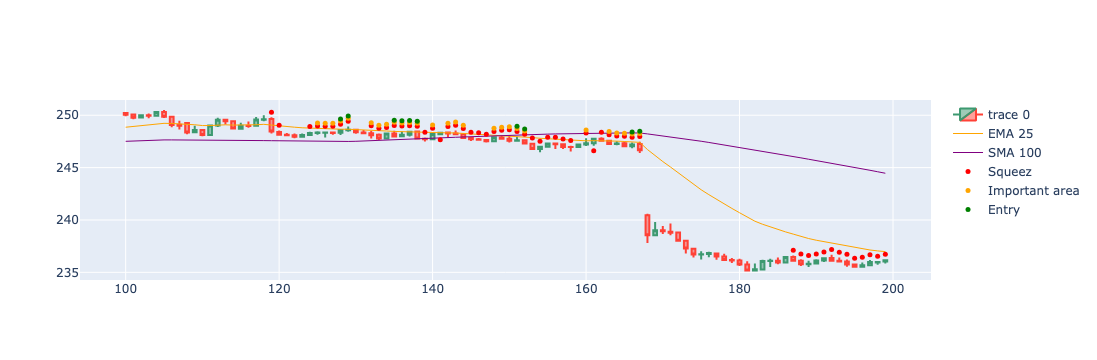

In [393]:
import plotly.io as pio
import plotly.graph_objects as go  

dfpl = df[100:200]

fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl.index,
            open=dfpl['open_5min'],
            high=dfpl['high_5min'],
            low=dfpl['low_5min'],
            close=dfpl['close_5min']),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema25'],
            line=dict(color='orange', width=1), 
            name="EMA 25"),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['sma100'],
            line=dict(color='purple', width=1), 
            name="SMA 100")
    ]
)

fig.add_scatter(x=dfpl.index, y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="red"), name="Squeez")
fig.add_scatter(x=dfpl.index, y=dfpl['squeezeCloseToEmaArea'], mode="markers", marker=dict(size=5, color="orange"), name="Important area")
fig.add_scatter(x=dfpl.index, y=dfpl['posibleBreakArea'], mode="markers", marker=dict(size=5, color="green"), name="Entry")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

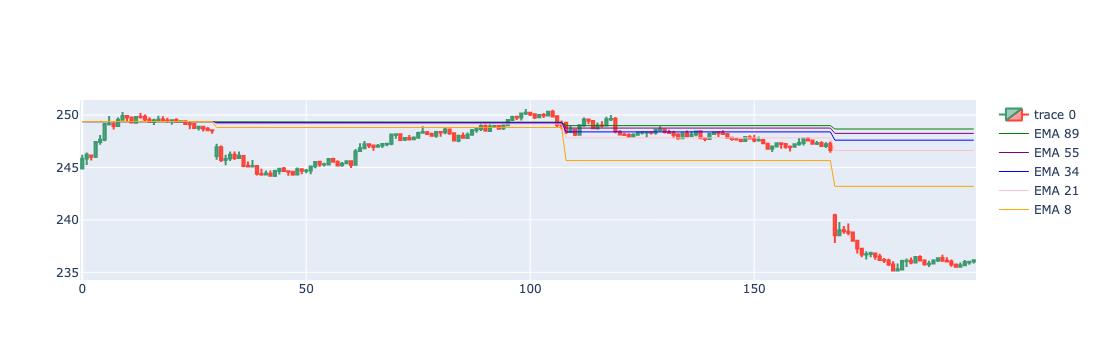

In [394]:
import plotly.io as pio
import plotly.graph_objects as go  

dfpl = df[100:200]

fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl.index,
            open=dfpl['open_5min'],
            high=dfpl['high_5min'],
            low=dfpl['low_5min'],
            close=dfpl['close_5min']),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema89'],
            line=dict(color='green', width=1), 
            name="EMA 89"),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema55'],
            line=dict(color='purple', width=1), 
            name="EMA 55"),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema34'],
            line=dict(color='blue', width=1), 
            name="EMA 34"),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema21'],
            line=dict(color='pink', width=1), 
            name="EMA 21"),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema8'],
            line=dict(color='orange', width=1), 
            name="EMA 8")
    ]
)

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()